In [1]:
# ============================================================================
# Part 3: Honest Evaluation - KNN Hyperparameter Tuning
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sys

sys.path.append("../src")

from knn import KNN
from metrics import accuracy, precision, recall, f1_score, roc_auc
from splits import stratified_split

np.random.seed(42)
sns.set_style("whitegrid")

print("Setup complete!")

Setup complete!


In [2]:
# ============================================================================
# Load Data
# ============================================================================

X = np.load("../X_full.npy")
y = np.load("../y_full.npy")

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Class distribution: {np.bincount(y.astype(int))}")

X shape: (1309, 8)
y shape: (1309,)
Class distribution: [809 500]


In [3]:
# ============================================================================
# 3.1 Stratified Split (60/20/20)
# ============================================================================

X_train, X_val, X_test, y_train, y_val, y_test = stratified_split(
    X, y, train_frac=0.6, val_frac=0.2, test_frac=0.2, seed=42
)

print("=" * 50)
print("STRATIFIED SPLIT RESULTS")
print("=" * 50)
print(
    f"Training set:   {len(X_train):4d} samples, positive class: {np.mean(y_train) * 100:.2f}%"
)
print(
    f"Validation set: {len(X_val):4d} samples, positive class: {np.mean(y_val) * 100:.2f}%"
)
print(
    f"Test set:       {len(X_test):4d} samples, positive class: {np.mean(y_test) * 100:.2f}%"
)
print(f"\nOverall positive class: {np.mean(y) * 100:.2f}%")

STRATIFIED SPLIT RESULTS
Training set:    785 samples, positive class: 38.22%
Validation set:  261 samples, positive class: 38.31%
Test set:        263 samples, positive class: 38.02%

Overall positive class: 38.20%


In [4]:
# ============================================================================
# 3.2 Hyperparameter Sweep over k
# ============================================================================

k_values = [1, 3, 5, 7, 9, 11, 15, 21, 31, 51]

results = {"k": [], "accuracy": [], "precision": [], "recall": [], "f1": [], "auc": []}

print("\nRunning hyperparameter sweep...")
print("-" * 70)

for k in k_values:
    knn = KNN(k=k, metric="euclidean", task="classification")
    knn.fit(X_train, y_train)

    y_pred = knn.predict(X_val)
    y_proba = knn.predict_proba(X_val)[:, 1]

    results["k"].append(k)
    results["accuracy"].append(accuracy(y_val, y_pred))
    results["precision"].append(precision(y_val, y_pred))
    results["recall"].append(recall(y_val, y_pred))
    results["f1"].append(f1_score(y_val, y_pred))
    results["auc"].append(roc_auc(y_val, y_proba))

    print(
        f"k={k:3d} | Acc={results['accuracy'][-1]:.4f} | Prec={results['precision'][-1]:.4f} | Rec={results['recall'][-1]:.4f} | F1={results['f1'][-1]:.4f} | AUC={results['auc'][-1]:.4f}"
    )

best_k_idx = np.argmax(results["f1"])
best_k = results["k"][best_k_idx]
print(f"\n✅ BEST k by validation F1: {best_k} (F1={results['f1'][best_k_idx]:.4f})")


Running hyperparameter sweep...
----------------------------------------------------------------------
k=  1 | Acc=0.6667 | Prec=0.5684 | Rec=0.5400 | F1=0.5538 | AUC=0.6427
k=  3 | Acc=0.6743 | Prec=0.5824 | Rec=0.5300 | F1=0.5550 | AUC=0.6910
k=  5 | Acc=0.7050 | Prec=0.6456 | Rec=0.5100 | F1=0.5698 | AUC=0.7304
k=  7 | Acc=0.7241 | Prec=0.6628 | Rec=0.5700 | F1=0.6129 | AUC=0.7443
k=  9 | Acc=0.7241 | Prec=0.6628 | Rec=0.5700 | F1=0.6129 | AUC=0.7514
k= 11 | Acc=0.7356 | Prec=0.6962 | Rec=0.5500 | F1=0.6145 | AUC=0.7554
k= 15 | Acc=0.7356 | Prec=0.7067 | Rec=0.5300 | F1=0.6057 | AUC=0.7333
k= 21 | Acc=0.7548 | Prec=0.7432 | Rec=0.5500 | F1=0.6322 | AUC=0.7293
k= 31 | Acc=0.7241 | Prec=0.6842 | Rec=0.5200 | F1=0.5909 | AUC=0.7325
k= 51 | Acc=0.7088 | Prec=0.6538 | Rec=0.5100 | F1=0.5730 | AUC=0.7193

✅ BEST k by validation F1: 21 (F1=0.6322)


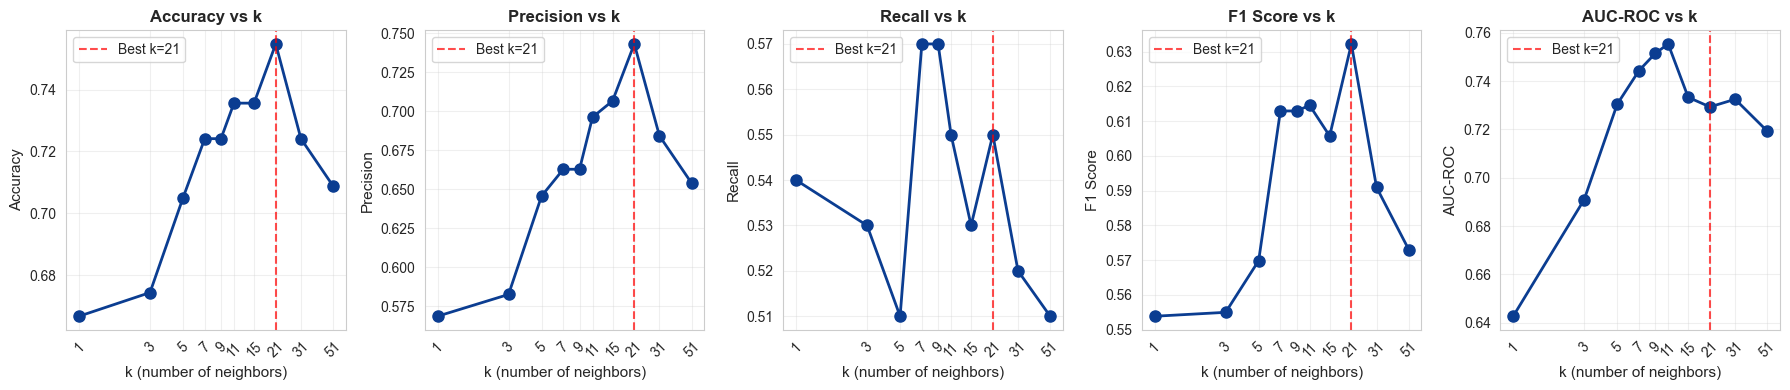

In [5]:
# ============================================================================
# Plot Hyperparameter Sweep Results
# ============================================================================

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

metrics = ["accuracy", "precision", "recall", "f1", "auc"]
titles = ["Accuracy", "Precision", "Recall", "F1 Score", "AUC-ROC"]

for i, (metric, title) in enumerate(zip(metrics, titles)):
    axes[i].plot(
        results["k"], results[metric], "o-", color="#0B3D91", linewidth=2, markersize=8
    )
    axes[i].axvline(
        x=best_k, color="red", linestyle="--", alpha=0.7, label=f"Best k={best_k}"
    )
    axes[i].set_xlabel("k (number of neighbors)", fontsize=11)
    axes[i].set_ylabel(title, fontsize=11)
    axes[i].set_title(f"{title} vs k", fontsize=12, fontweight="bold")
    axes[i].set_xscale("log")
    axes[i].set_xticks(k_values)
    axes[i].set_xticklabels(k_values, rotation=45)
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("../figures/hyperparameter_sweep.png", dpi=300, bbox_inches="tight")
plt.show()

In [6]:
# ============================================================================
# Best k by each metric
# ============================================================================

print("\nBest k by each metric:")
print("-" * 35)
for metric in ["accuracy", "precision", "recall", "f1", "auc"]:
    best_idx = np.argmax(results[metric])
    print(
        f"  {metric.capitalize():10s}: k={results['k'][best_idx]:2d} (value={results[metric][best_idx]:.4f})"
    )


Best k by each metric:
-----------------------------------
  Accuracy  : k=21 (value=0.7548)
  Precision : k=21 (value=0.7432)
  Recall    : k= 7 (value=0.5700)
  F1        : k=21 (value=0.6322)
  Auc       : k=11 (value=0.7554)


In [7]:
# ============================================================================
# 3.3 Baseline Comparisons
# ============================================================================

from sklearn.neighbors import KNeighborsClassifier

# Our best KNN
knn_best = KNN(k=best_k, metric="euclidean", task="classification")
knn_best.fit(X_train, y_train)
y_pred_best = knn_best.predict(X_val)
y_proba_best = knn_best.predict_proba(X_val)[:, 1]

# sklearn KNN
knn_sklearn = KNeighborsClassifier(n_neighbors=best_k, metric="euclidean")
knn_sklearn.fit(X_train, y_train)
y_pred_sklearn = knn_sklearn.predict(X_val)
y_proba_sklearn = knn_sklearn.predict_proba(X_val)[:, 1]

# Majority baseline
majority_class = np.bincount(y_train.astype(int)).argmax()
y_pred_majority = np.full(len(y_val), majority_class)

print("\n" + "=" * 70)
print("BASELINE COMPARISON (Validation Set)")
print("=" * 70)
print(
    f"{'Model':<25} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1':<10} {'AUC':<10}"
)
print("-" * 70)
print(
    f"{'Our KNN (k=' + str(best_k) + ')':<25} {accuracy(y_val, y_pred_best):<10.4f} {precision(y_val, y_pred_best):<10.4f} {recall(y_val, y_pred_best):<10.4f} {f1_score(y_val, y_pred_best):<10.4f} {roc_auc(y_val, y_proba_best):<10.4f}"
)
print(
    f"{'sklearn KNN':<25} {accuracy(y_val, y_pred_sklearn):<10.4f} {precision(y_val, y_pred_sklearn):<10.4f} {recall(y_val, y_pred_sklearn):<10.4f} {f1_score(y_val, y_pred_sklearn):<10.4f} {roc_auc(y_val, y_proba_sklearn):<10.4f}"
)
print(
    f"{'Majority Baseline':<25} {accuracy(y_val, y_pred_majority):<10.4f} {precision(y_val, y_pred_majority):<10.4f} {recall(y_val, y_pred_majority):<10.4f} {f1_score(y_val, y_pred_majority):<10.4f} {'N/A':<10}"
)


BASELINE COMPARISON (Validation Set)
Model                     Accuracy   Precision  Recall     F1         AUC       
----------------------------------------------------------------------
Our KNN (k=21)            0.7548     0.7432     0.5500     0.6322     0.7293    
sklearn KNN               0.7548     0.7432     0.5500     0.6322     0.7298    
Majority Baseline         0.6169     0.0000     0.0000     0.0000     N/A       


In [8]:
# ============================================================================
# 3.4 Final Test Set Evaluation (ONCE!)
# ============================================================================

print("\n" + "=" * 70)
print("FINAL TEST SET EVALUATION (Used exactly once!)")
print("=" * 70)

# Train on train+val with best k
X_train_full = np.vstack([X_train, X_val])
y_train_full = np.concatenate([y_train, y_val])

knn_final = KNN(k=best_k, metric="euclidean", task="classification")
knn_final.fit(X_train_full, y_train_full)

y_test_pred = knn_final.predict(X_test)
y_test_proba = knn_final.predict_proba(X_test)[:, 1]

print(f"\nTest Set Results (k={best_k}):")
print("-" * 40)
print(f"  Accuracy:  {accuracy(y_test, y_test_pred):.4f}")
print(f"  Precision: {precision(y_test, y_test_pred):.4f}")
print(f"  Recall:    {recall(y_test, y_test_pred):.4f}")
print(f"  F1 Score:  {f1_score(y_test, y_test_pred):.4f}")
print(f"  AUC-ROC:   {roc_auc(y_test, y_test_proba):.4f}")

# Compare with validation
print("\nComparison: Validation vs Test")
print("-" * 40)
print("  Metric     | Validation | Test")
print("  -----------|------------|-------")
print(
    f"  Accuracy   | {results['accuracy'][best_k_idx]:.4f}     | {accuracy(y_test, y_test_pred):.4f}"
)
print(
    f"  Precision  | {results['precision'][best_k_idx]:.4f}     | {precision(y_test, y_test_pred):.4f}"
)
print(
    f"  Recall     | {results['recall'][best_k_idx]:.4f}     | {recall(y_test, y_test_pred):.4f}"
)
print(
    f"  F1         | {results['f1'][best_k_idx]:.4f}     | {f1_score(y_test, y_test_pred):.4f}"
)
print(
    f"  AUC        | {results['auc'][best_k_idx]:.4f}     | {roc_auc(y_test, y_test_proba):.4f}"
)


FINAL TEST SET EVALUATION (Used exactly once!)

Test Set Results (k=21):
----------------------------------------
  Accuracy:  0.6882
  Precision: 0.6184
  Recall:    0.4700
  F1 Score:  0.5341
  AUC-ROC:   0.7537

Comparison: Validation vs Test
----------------------------------------
  Metric     | Validation | Test
  -----------|------------|-------
  Accuracy   | 0.7548     | 0.6882
  Precision  | 0.7432     | 0.6184
  Recall     | 0.5500     | 0.4700
  F1         | 0.6322     | 0.5341
  AUC        | 0.7293     | 0.7537
